### **Overview**
This project addresses one of the most critical challenges in the banking and financial sector evaluating loan applications efficiently and accurately.

Traditional manual processes are slow, inconsistent, and prone to human bias.

### **Project Objective**
The goal is to train a binary classification model using features such as:

* Annual Income
* Credit Score
* Total Assets
* Loan Amount
* Employment Information  

The model supports faster, fairer, and data-driven lending decisions.

### **Business Impact**
* Identify low-risk applicants for approval
* Flag high-risk applicants
* Reduce manual review time
* Minimize human error
* Ensure consistent decision criteria

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"C:\Users\Isha Jaikumar\Downloads\loan_approval_dataset.csv")
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,-,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,NaN,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [3]:
## Data Preprocessing
df.describe(include="all")

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,4269.000000,4269,4269,4251,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269
unique,NaN,7,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,4,Graduate,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Approved
freq,NaN,752,2144,2150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2656
mean,2135.000000,NaN,NaN,NaN,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06,NaN
std,1232.498479,NaN,NaN,NaN,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06,NaN
min,1.000000,NaN,NaN,NaN,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00,NaN
25%,1068.000000,NaN,NaN,NaN,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,NaN
50%,2135.000000,NaN,NaN,NaN,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,NaN
75%,3202.000000,NaN,NaN,NaN,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   object
 2    education                 4269 non-null   object
 3    self_employed             4251 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(9), object(4)
memory usage: 433.7+ KB


In [5]:
# HANDLING MISSING VALUES
df.isnull().sum()

loan_id                       0
 no_of_dependents             0
 education                    0
 self_employed               18
 income_annum                 0
 loan_amount                  0
 loan_term                    0
 cibil_score                  0
 residential_assets_value     0
 commercial_assets_value      0
 luxury_assets_value          0
 bank_asset_value             0
 loan_status                  0
dtype: int64

In [6]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [7]:
df[' self_employed'].value_counts()

 self_employed
Yes    2150
No     2101
Name: count, dtype: int64

In [8]:
df[' self_employed'].mode()

0     Yes
Name:  self_employed, dtype: object

In [9]:
df[' self_employed'].unique()

array([' No', ' Yes', nan], dtype=object)

In [10]:
df[" self_employed"].fillna(' No',inplace=True)

In [11]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [12]:
# Finding unique values in dataset
for i in df.columns:
  print({i:df[i].unique()})

{'loan_id': array([   1,    2,    3, ..., 4267, 4268, 4269])}
{' no_of_dependents': array(['2', '-', '3', '5', '0', '4', '1'], dtype=object)}
{' education': array([' Graduate', ' Not Graduate'], dtype=object)}
{' self_employed': array([' No', ' Yes'], dtype=object)}
{' income_annum': array([9600000, 4100000, 9100000, 8200000, 9800000, 4800000, 8700000,
       5700000,  800000, 1100000, 2900000, 6700000, 5000000, 1900000,
       4700000,  500000, 2700000, 6300000, 5800000, 6500000, 4900000,
       3100000, 2400000, 7000000, 9000000, 8400000, 1700000, 1600000,
       8000000, 3600000, 1500000, 7800000, 1400000, 4200000, 5500000,
       9500000, 7300000, 3800000, 5100000, 4300000, 9300000, 7400000,
       8500000, 8800000, 3300000, 3900000, 8300000, 5600000, 5300000,
       2600000,  700000, 3500000, 9900000, 3000000, 6800000, 2000000,
       1000000,  300000, 6600000, 9400000, 4400000,  400000, 6200000,
       9700000, 7100000,  600000, 7200000,  900000,  200000, 1800000,
       4600000,

In [13]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [14]:
# HANDLING WRONG DATA
df[df[' no_of_dependents']=="-"]

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,2,-,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
8,9,-,Graduate,Yes,800000,2200000,20,782,1300000,800000,2800000,600000,Approved
23,24,-,Not Graduate,Yes,500000,1400000,2,551,900000,600000,1100000,300000,Approved
247,248,-,Not Graduate,Yes,9400000,27000000,10,536,4400000,1700000,33800000,4800000,Rejected


In [15]:
df.replace("-",np.nan,inplace=True)

In [16]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            4
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [17]:
df[" no_of_dependents"].value_counts()

 no_of_dependents
4    752
3    727
2    708
0    708
1    697
5    673
Name: count, dtype: int64

In [18]:
df[" no_of_dependents"].fillna(0,inplace=True)

In [19]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [20]:
df.dtypes

loan_id                       int64
 no_of_dependents            object
 education                   object
 self_employed               object
 income_annum                 int64
 loan_amount                  int64
 loan_term                    int64
 cibil_score                  int64
 residential_assets_value     int64
 commercial_assets_value      int64
 luxury_assets_value          int64
 bank_asset_value             int64
 loan_status                 object
dtype: object

In [21]:
#CONVERTING DATA TYPE
df[" no_of_dependents"] = df[" no_of_dependents"].astype(int)

In [22]:
df.dtypes

loan_id                       int64
 no_of_dependents             int64
 education                   object
 self_employed               object
 income_annum                 int64
 loan_amount                  int64
 loan_term                    int64
 cibil_score                  int64
 residential_assets_value     int64
 commercial_assets_value      int64
 luxury_assets_value          int64
 bank_asset_value             int64
 loan_status                 object
dtype: object

In [23]:
df[df[' residential_assets_value']<0]

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
59,60,4,Not Graduate,Yes,5500000,18200000,16,797,-100000,4900000,18600000,4800000,Approved
196,197,4,Not Graduate,Yes,400000,1500000,2,669,-100000,600000,900000,500000,Approved
559,560,2,Graduate,Yes,200000,500000,6,885,-100000,0,300000,200000,Rejected
702,703,4,Graduate,Yes,6300000,23900000,6,899,-100000,11400000,20600000,6700000,Approved
737,738,2,Graduate,Yes,900000,2500000,16,458,-100000,100000,3200000,1100000,Rejected
784,785,0,Graduate,No,5000000,14400000,2,761,-100000,7300000,12600000,4500000,Approved
904,905,2,Graduate,No,4100000,14900000,12,571,-100000,5200000,13000000,3400000,Approved
1089,1090,3,Graduate,No,5100000,11000000,6,336,-100000,5800000,11600000,7500000,Rejected
1163,1164,2,Graduate,No,4500000,9100000,18,593,-100000,600000,12400000,2500000,Approved
1350,1351,5,Graduate,No,4000000,13700000,6,496,-100000,1400000,15800000,3700000,Rejected


In [24]:
# CONVERTING -VE ASSET VALUES TO 0
df.loc[df[' residential_assets_value']<0," residential_assets_value"] = 0

In [25]:
df[' residential_assets_value'].describe()

count    4.269000e+03
mean     7.473272e+06
std      6.502878e+06
min      0.000000e+00
25%      2.200000e+06
50%      5.600000e+06
75%      1.130000e+07
max      2.910000e+07
Name:  residential_assets_value, dtype: float64

In [26]:
# FINDING DUPLICATE ENTRIES
df.duplicated().sum()

np.int64(0)

In [27]:
df['loan_id'].nunique()

4269

In [28]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [29]:
# FEATURE SELECTION
# Loan ID according to the domain is not relevant & not required for further analysis
df.drop("loan_id",axis=1,inplace=True)

In [30]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [31]:
# EDA
df.columns

Index([' no_of_dependents', ' education', ' self_employed', ' income_annum',
       ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

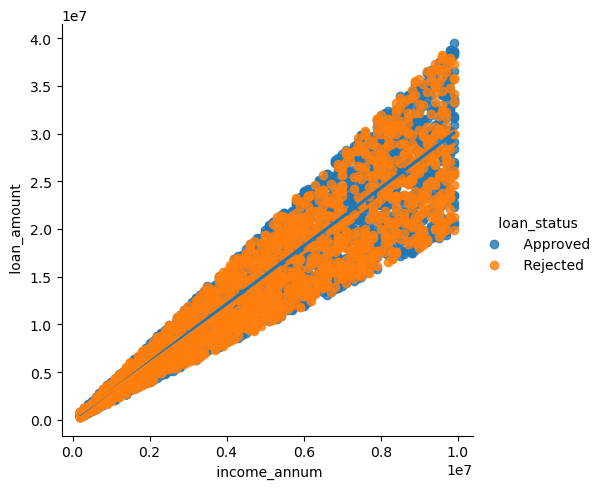

In [32]:
# How annual income and loan amount relate to each other
sns.lmplot(data=df, x=' income_annum', y=' loan_amount', hue=' loan_status');

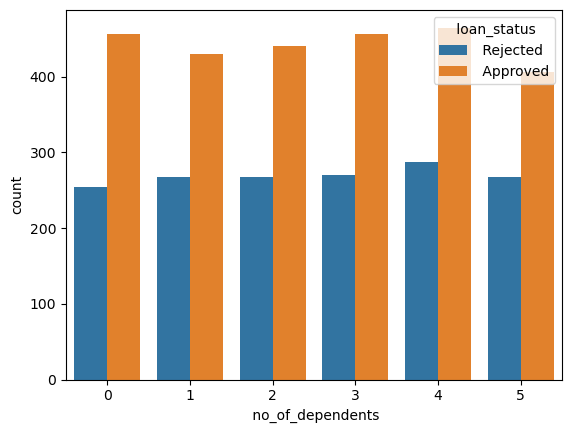

In [33]:
# How does loan approval get impacted on the basis of no.of dependents
# Also show approoval or rejection
sns.countplot(data=df, x=' no_of_dependents', hue=' loan_status');

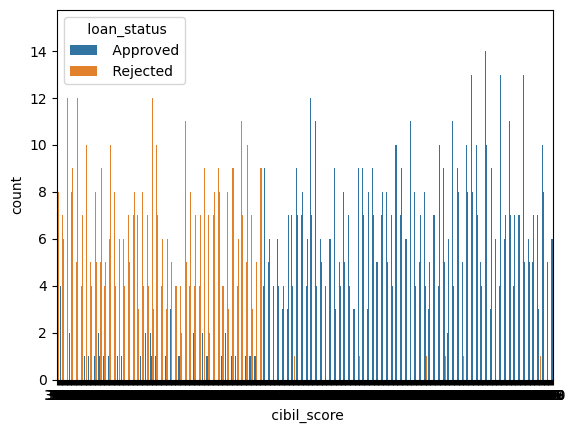

In [34]:
# How does cibil score impact loan approval
sns.countplot(data=df, x=' cibil_score', hue=' loan_status');

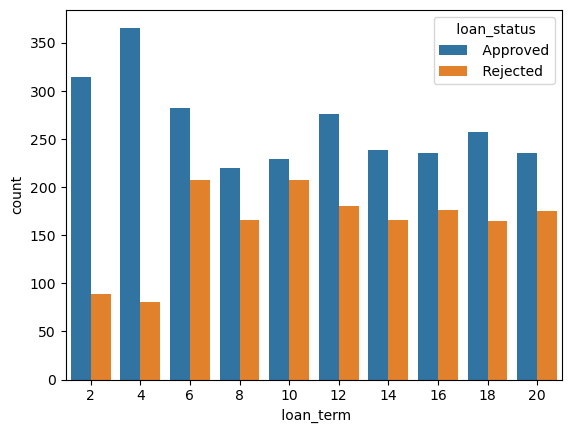

In [35]:
# How loan term impacts loan approval
sns.countplot(data=df, x=' loan_term', hue=' loan_status');

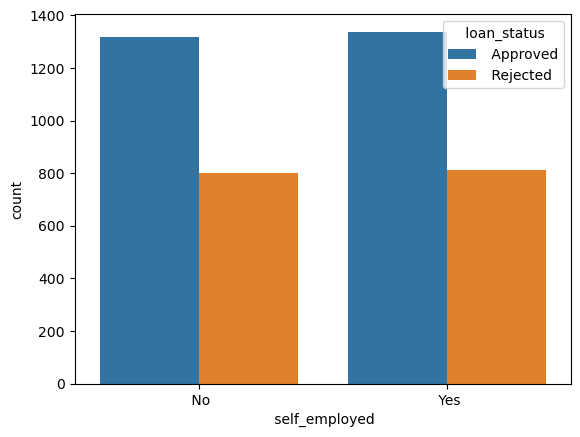

In [36]:
# How self-employment affects loan approval
sns.countplot(data=df, x=' self_employed', hue=' loan_status');

In [37]:
df.dtypes

no_of_dependents             int64
education                   object
self_employed               object
income_annum                 int64
loan_amount                  int64
loan_term                    int64
cibil_score                  int64
residential_assets_value     int64
commercial_assets_value      int64
luxury_assets_value          int64
bank_asset_value             int64
loan_status                 object
dtype: object

In [38]:
# DATA TRANSFORMATION

cols =[]
for i in df.columns:
    if df[i].dtypes == "object":
        cols.append(i)
print(cols)

[' education', ' self_employed', ' loan_status']


In [39]:
# Transforming education column wuith get_dummies
df = pd.get_dummies(df, columns=[' education'])
df

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_ Graduate,education_ Not Graduate
0,2,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved,True,False
1,0,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected,False,True
2,3,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected,True,False
3,3,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected,True,False
4,5,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected,True,False
4265,0,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved,False,True
4266,2,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected,False,True
4267,1,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved,False,True


In [40]:
df.columns

Index([' no_of_dependents', ' self_employed', ' income_annum', ' loan_amount',
       ' loan_term', ' cibil_score', ' residential_assets_value',
       ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value',
       ' loan_status', ' education_ Graduate', ' education_ Not Graduate'],
      dtype='object')

In [41]:
df.drop(' education_ Not Graduate', axis=1, inplace=True)
df

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_ Graduate
0,2,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved,True
1,0,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected,False
2,3,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected,True
3,3,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected,True
4,5,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected,False
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected,True
4265,0,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved,False
4266,2,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected,False
4267,1,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved,False


In [42]:
# Mnual Mappimg of data

df[' self_employed'] = df[' self_employed'].map({' Yes':1, ' No':0})
df

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_ Graduate
0,2,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved,True
1,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected,False
2,3,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected,True
3,3,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected,True
4,5,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected,False
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected,True
4265,0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved,False
4266,2,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected,False
4267,1,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved,False


In [43]:
df[' loan_status']. value_counts()

 loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [44]:
df[' loan_status'] = df[' loan_status'].map({" Approved":1, " Rejected":0})
df

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_ Graduate
0,2,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,True
1,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,False
2,3,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,True
3,3,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,True
4,5,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0,True
4265,0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1,False
4266,2,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0,False
4267,1,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,1,False


In [45]:
df.dtypes

no_of_dependents            int64
self_employed               int64
income_annum                int64
loan_amount                 int64
loan_term                   int64
cibil_score                 int64
residential_assets_value    int64
commercial_assets_value     int64
luxury_assets_value         int64
bank_asset_value            int64
loan_status                 int64
education_ Graduate          bool
dtype: object

In [46]:
df.columns

Index([' no_of_dependents', ' self_employed', ' income_annum', ' loan_amount',
       ' loan_term', ' cibil_score', ' residential_assets_value',
       ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value',
       ' loan_status', ' education_ Graduate'],
      dtype='object')

In [47]:
df[' loan_status'].value_counts()

 loan_status
1    2656
0    1613
Name: count, dtype: int64

In [48]:
X = df.drop(' loan_status', axis=1)
Y = df[' loan_status']

In [49]:
Y.shape

(4269,)

In [50]:
df.shape

(4269, 12)

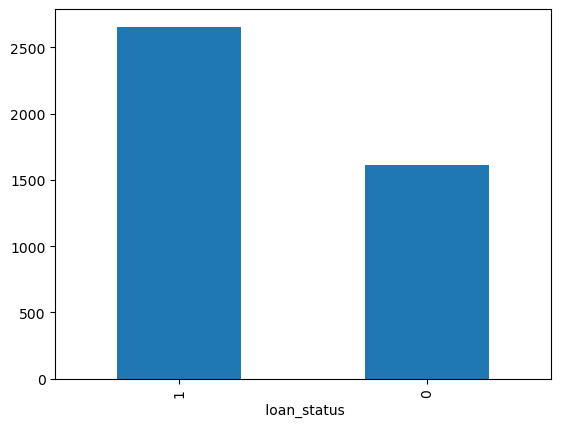

In [51]:
df[' loan_status'].value_counts().plot(kind ='bar');

In [52]:
df.shape   # Training (historic data)------ train and validation split
# I have another datafile which client has given me for testing and that is my unseen data ---> Testinf split 1000

(4269, 12)

In [53]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaler.fit(X)
X = scaler.transform(X)
# X=scaler.fit_transform
# print(X)

In [54]:
from sklearn.model_selection import train_test_split

# Split the data into test and train
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.25,random_state=10)

In [55]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(3201, 11)
(3201,)
(1068, 11)
(1068,)
